In [17]:
import pandas as pd
df_all = pd.read_csv("../../generated/cdrs/seq/all_data.tsv", sep="\t")

#df_all.dropna(inplace=True)
df_all


,pdb,heavy_chain,CDR_H3,CDR_H2,CDR_H1,CDR_H1_count_A,CDR_H1_count_R,CDR_H1_count_N,CDR_H1_count_D,CDR_H1_count_C,...,CDR_H3_mean_charge,CDR_H3_mean_polarity,CDR_H3_mean_mass,cdr_h1_length,cdr_h2_length,cdr_h3_length,CDR_H1_length,CDR_H2_length,CDR_H3_length,source
0,8rmx,E,RFVGTLDV,FWDDD,GFSLDTSGV,0.0,0.0,0.0,1.0,0.0,...,0.000000,7.875000,113.255000,9,5,8,9,5,8,human
1,8rmy,E,RFVGTLDV,FWDDD,GFSLDTSGV,0.0,0.0,0.0,1.0,0.0,...,0.000000,7.875000,113.255000,9,5,8,9,5,8,human
2,8znz,F,AIYYYGSSYNYYAMDY,SSGGGY,GFTFSKY,0.0,0.0,0.0,0.0,0.0,...,-0.062500,7.656250,125.449375,7,6,16,7,6,16,human
3,9avo,B,GYGWALDY,YPYYGS,GFNVSYY,0.0,0.0,1.0,0.0,0.0,...,-0.125000,7.725000,120.251250,7,6,8,7,6,8,human
4,9awe,B,GYGWALDY,YPYYGS,GFNVSYY,0.0,0.0,1.0,0.0,0.0,...,-0.125000,7.725000,120.251250,7,6,8,7,6,8,human
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
956,7chp,H,DLQEHGMDV,YSGGS,GFTVSSN,0.0,0.0,1.0,0.0,0.0,...,-0.222222,9.411111,115.901111,7,5,9,7,5,9,sars_cov2
957,7n4i,H,LLYYSDSSPLDS,YPGDSD,GYSFISY,0.0,0.0,0.0,0.0,0.0,...,-0.166667,8.158333,111.788333,7,6,12,7,6,12,sars_cov2
958,7l7d,H,PYCSSISCNDGFDI,VIGSGN,GFTFMSS,0.0,0.0,0.0,0.0,0.0,...,-0.142857,8.214286,108.620000,7,6,14,7,6,14,sars_cov2
959,7n3d,H,HSRIEVAGTLDFDY,YYSGN,GGSISSY,0.0,0.0,0.0,0.0,0.0,...,-0.071429,8.678571,115.911429,7,5,14,7,5,14,sars_cov2


In [18]:
import pandas as pd
import numpy as np
# %pip install biopython
# Load the datasets from the specified paths
df_data = df_all

CDR_H3_sequences = df_data["CDR_H3"].tolist() # spalte CDR_H3 als liste
CDR_H2_sequences = df_data["CDR_H2"].tolist() # spalte CDR_H2 als liste
CDR_H1_sequences = df_data["CDR_H1"].tolist() # spalte CDR_H1 als liste
CDR=0 # cdr auswahl, 0 = H3, 1 = H2, 2 = H1
df_data.head()
extra_data_names = df_data.columns.tolist()[5:17] # spaltennamen als liste, ab so hydophobicity und so
extracted_data = df_data[extra_data_names].values.T # transformierte matrix, d.h. die einzelnen pdbs sind jetzt spalten, statt zeilen
print("Extracted data shape:", extracted_data.shape)
print("feature 1:", extra_data_names[0],extracted_data[0].shape)

# Check for 'nan' values in CDR_H3 sequences
for i,seq in enumerate(CDR_H3_sequences):
    if seq == "nan":
        print(i)
print("Number of CDR_H3 sequences with 'nan':", sum(seq == CDR_H2_sequences[0] for seq in CDR_H3_sequences))
print("Number of CDR_H2 sequences with 'nan':", sum(seq == "nan" for seq in CDR_H2_sequences))
print("Number of CDR_H1 sequences with 'nan':", sum(seq == "nan" for seq in CDR_H1_sequences)) # no missing values 

# Check for 'n' values in CDR_H2 sequences
# 'n' values are not expected, but checking for them
for i,seq in enumerate(CDR_H2_sequences):
    if seq == "n":
        print(i)
print(CDR_H2_sequences[:10])

Extracted data shape: (12, 961)
feature 1: CDR_H1_count_A (961,)
Number of CDR_H3 sequences with 'nan': 0
Number of CDR_H2 sequences with 'nan': 0
Number of CDR_H1 sequences with 'nan': 0
['FWDDD', 'FWDDD', 'SSGGGY', 'YPYYGS', 'YPYYGS', 'SYDGRH', 'IPVIDD', 'IPRLDA', 'NPNSGG', 'YWDHN']


In [19]:

def get_cleaned_sequences():
    """
    Cleans the sequences by removing non-string entries.
    """

    return [seq for seq in sequences if isinstance(seq, str)]
# Filter out non-string (e.g., NaN) entries
dirty_indices_h3 = [i for i, seq in enumerate(CDR_H3_sequences) if isinstance(seq, float)]
dirty_indices_h2 = [i for i, seq in enumerate(CDR_H2_sequences) if isinstance(seq, float)]
dirty_indices_h1 = [i for i, seq in enumerate(CDR_H1_sequences) if isinstance(seq, float)]
#combine the dirty indices
dirty_indices = set(dirty_indices_h3 + dirty_indices_h2 + dirty_indices_h1)
sorted_dirty_indices = sorted(dirty_indices)
# Clean the sequences by removing non-string entries
CDR_H3_sequences_clean = [seq for i, seq in enumerate(CDR_H3_sequences) if i not in dirty_indices]
CDR_H2_sequences_clean = [seq for i, seq in enumerate(CDR_H2_sequences) if i not in dirty_indices]
CDR_H1_sequences_clean = [seq for i, seq in enumerate(CDR_H1_sequences) if i not in dirty_indices]
# clean the extracted data by removing the dirty indices
extracted_data_clean = np.delete(extracted_data, sorted_dirty_indices, axis=1)
#print the dirty indices
print("Dirty indices:", sorted_dirty_indices)

# CDR_H3_sequences_clean = [seq for seq in CDR_H3_sequences if isinstance(seq, str)]
# CDR_H2_sequences_clean = [seq for seq in CDR_H2_sequences if isinstance(seq, str)]
# CDR_H1_sequences_clean = [seq for seq in CDR_H1_sequences if isinstance(seq, str)]

# max length of cdr sequences (for array)
max_length_h3 = max(len(seq) for seq in CDR_H3_sequences_clean)
max_length_h2 = max(len(seq) for seq in CDR_H2_sequences_clean)
max_length_h1 = max(len(seq) for seq in CDR_H1_sequences_clean)

print("Max length of CDR_H3 sequences:", max_length_h3) #cdrh3 haben die längsten cdr sequenzen
print("number of CDR_H3 sequences:", len(CDR_H3_sequences_clean))
print("number OF CDR_H2 sequences:", len(CDR_H2_sequences_clean))
print("number of CDR_H1 sequences:", len(CDR_H1_sequences_clean))

Dirty indices: []
Max length of CDR_H3 sequences: 26
number of CDR_H3 sequences: 961
number OF CDR_H2 sequences: 961
number of CDR_H1 sequences: 961


In [20]:
# feature matrix um sequenzen einheitlich als vektoren darzustellen
import numpy as np

# Function um eine sequnece in eine numerische Darstellung umzuwandeln
def onehot_of_sequence(seq, aa_list,length:int = None):
    if length is None:
        length = len(seq)
    aa_to_idx = {aa: i for i, aa in enumerate(aa_list)} # erzeugt dictionary
    onehot = np.zeros((length, len(aa_list)), dtype=int) # erzeugt matrix mit nullen (26x21)
    for i, aa in enumerate(seq): # für jede AS in der sequenz, wird an der passenden stelle eine 1 gesetzt
        idx = aa_to_idx.get(aa, aa_to_idx["-"])  # Handle unknown amino acids
        onehot[i, idx] = 1
    onehot = onehot.flatten()  # verwandelt matrix in vektor
    return onehot

#beispiel
example_embedding = onehot_of_sequence("CASSLGTGQYF", "ACDEFGHIKLMNPQRSTVWY-",length=1000) 
print("onehot_of_sequence:", example_embedding, "shape:", example_embedding.shape)

onehot_of_sequence: [0 1 0 ... 0 0 0] shape: (21000,)


In [21]:
def embedding_of_CDRs(CDRs=["H3"], aa_list = "ACDEFGHIKLMNPQRSTVWY-"): # definiere eine funktion, die
    #load the dataframe
    df_data = pd.read_csv("../../generated/cdrs/seq/all_data.tsv", sep="\t")
    n_data = len(df_data[f"CDR_{CDRs[0]}"].tolist()) # Anzahl der Sequenzen in CDR_H3
    All_CDR_sequences = []  # Liste für alle CDR-Sequenzen
    #dirty_indices = set()  # Set für schmutzige Indizes
    for CDR in CDRs:
        CDR_sequences = df_data[f"CDR_{CDR}"].tolist()
        # get the dirty indices for the current CDR
        dirty_indices_CDR = [i for i, seq in enumerate(CDR_sequences) if not isinstance(seq, str)]
        dirty_indices.update(dirty_indices_CDR)  # Update the set with dirty indices
        All_CDR_sequences.append(CDR_sequences)  # Append the sequences to the list
    # sort the dirty indices
    sorted_dirty_indices = sorted(dirty_indices) # 
    print("Dirty indices:", sorted_dirty_indices)
    n_data = n_data - len(sorted_dirty_indices)  # Update n_data to account for removed sequences
    embedding = np.zeros((n_data, 1), dtype=float)  # Initialize embedding array with zeros
    for CDR_sequences in All_CDR_sequences:
        # Clean the sequences by removing non-string entries
        CDR_sequences = [seq for i, seq in enumerate(CDR_sequences) if i not in dirty_indices]
        max_length_h1 = max(len(seq) for seq in CDR_sequences)
        n_features = len(aa_list) * max_length_h1
        onehot = np.zeros((n_data, n_features), dtype=int)
        for i in range(len(CDR_sequences)):
            seq = CDR_sequences[i]
            seq_onehot = onehot_of_sequence(seq, aa_list, length=max_length_h1)
            onehot[i, :] = seq_onehot
        print("onehot shape:", onehot.shape)
        embedding = np.concatenate((embedding, onehot), axis=1)
        
        #add the extracted data
        extra_data_names = df_data.columns.tolist()[5:17]
        
        #filter the extracted data for the current CDR
        for extra_data_name in extra_data_names:
            if CDR in extra_data_name:
                extracted_data = df_data[extra_data_name].values.reshape(-1, 1)  # Reshape to (n_data, 1)
                print(f"Extracted data for {extra_data_name} shape:", extracted_data.shape)
                #filter the extracted data for the current CDR
                extracted_data = np.delete(extracted_data, sorted_dirty_indices, axis=0)
                embedding = np.concatenate((embedding, extracted_data), axis=1)
    print("embedding shape:", embedding.shape)
    # Exclude the first row which is all zeros
    embedding = embedding[:, 1:]  # Exclude the first row which is all zeros
    print("Final embedding shape:", embedding.shape)
    return embedding,sorted_dirty_indices  # Exclude the first row which is all zeros



In [22]:
embedding,sorted_dirty_indices=embedding_of_CDRs(["H3","H2","H1"])

Dirty indices:

 []
onehot shape: (961, 546)
Extracted data for CDR_H1_count_A shape: (961, 1)
Extracted data for CDR_H1_count_R shape: (961, 1)
Extracted data for CDR_H1_count_N shape: (961, 1)
Extracted data for CDR_H1_count_D shape: (961, 1)
Extracted data for CDR_H1_count_C shape: (961, 1)
Extracted data for CDR_H1_count_Q shape: (961, 1)
Extracted data for CDR_H1_count_E shape: (961, 1)
Extracted data for CDR_H1_count_G shape: (961, 1)
Extracted data for CDR_H1_count_H shape: (961, 1)
Extracted data for CDR_H1_count_I shape: (961, 1)
Extracted data for CDR_H1_count_L shape: (961, 1)
Extracted data for CDR_H1_count_K shape: (961, 1)
onehot shape: (961, 210)
Extracted data for CDR_H1_count_A shape: (961, 1)
Extracted data for CDR_H1_count_R shape: (961, 1)
Extracted data for CDR_H1_count_N shape: (961, 1)
Extracted data for CDR_H1_count_D shape: (961, 1)
Extracted data for CDR_H1_count_C shape: (961, 1)
Extracted data for CDR_H1_count_Q shape: (961, 1)
Extracted data for CDR_H1_count_E shape: (961,

C:\Users\082mi\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
C:\Users\082mi\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


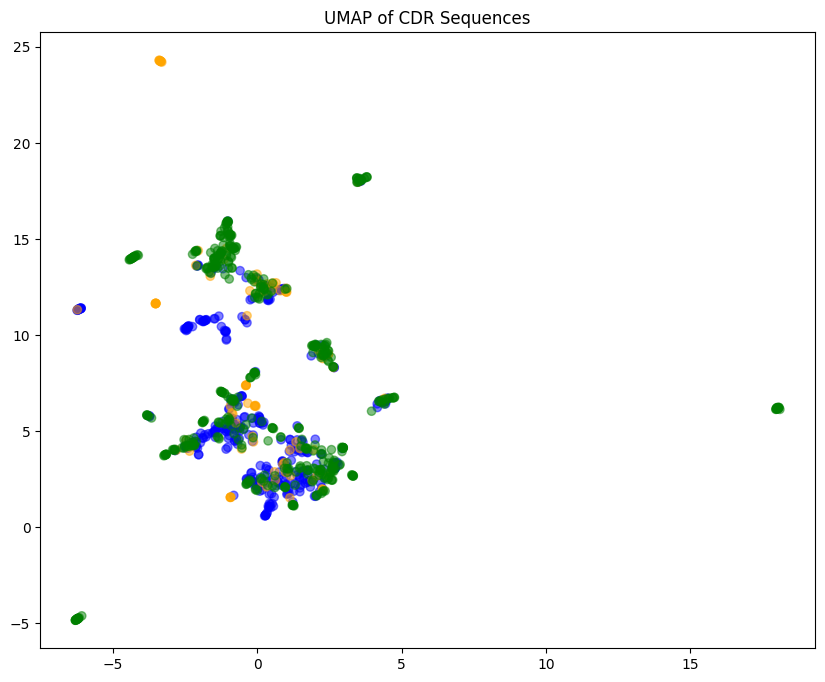

In [23]:
import umap.umap_ as umap  # UMAP import
umap_model = umap.UMAP(n_components=2, random_state=42)
umap_result = umap_model.fit_transform(embedding)
import matplotlib.pyplot as plt
df_nm = pd.read_csv("../../generated/cdrs/seq/all_data.tsv", sep="\t")
# Step 6: Create UMAP result DataFrame
color = []
for i in df_nm["source"].values:
    if i == "human":
        color.append("blue")
    elif i == "influenza":
        color.append("orange")
    elif i == "sars_cov2":
        color.append("green")
    else:
        color.append("gray")
#drop the dirty indices from the color list
color = [color[i] for i in range(len(color)) if i not in sorted_dirty_indices]
plt.figure(figsize=(10, 8))
plt.scatter(umap_result[:, 0], umap_result[:, 1], alpha=0.5, c=color)
plt.title("UMAP of CDR Sequences")
plt.show()

Text(0.5, 1.0, 'KMeans Clustering of CDR Sequences')

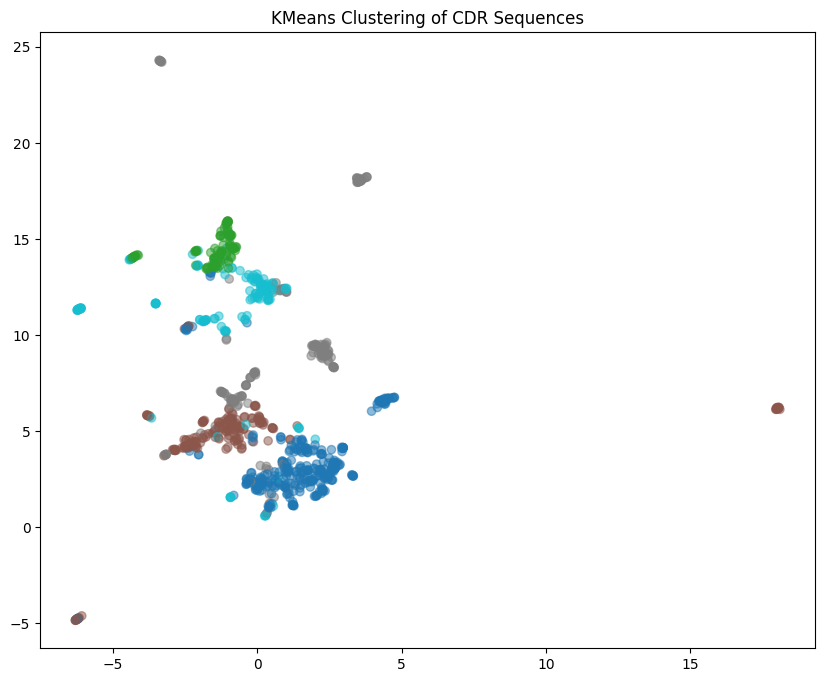

In [24]:
#crate a kmeans clustering model
from sklearn.cluster import KMeans
kmeans = KMeans(n_clusters=5, random_state=42)
kmeans.fit(embedding)
# Predict the cluster labels
cluster_labels = kmeans.predict(embedding)

plt.figure(figsize=(10, 8))
plt.scatter(umap_result[:, 0], umap_result[:, 1], alpha=0.5, c=cluster_labels, cmap='tab10')
plt.title("KMeans Clustering of CDR Sequences") 

In [25]:
# train a logistic regression model
from sklearn.linear_model import LogisticRegression
embedding,dirty_indices = embedding_of_CDRs(["H3","H2","H1"])
#shuffle the data
indexes = np.arange(embedding.shape[0])
np.random.seed(100)
np.random.shuffle(indexes)
embedding = embedding[indexes]
labels = df_all["source"].values
#clean the labels by removing the dirty indices
labels = [labels[i] for i in range(len(labels)) if i not in dirty_indices]
#shuffle the labels
labels = np.array(labels)[indexes]  # Shuffle the labels to match the shuffled embedding
model = LogisticRegression(max_iter=int(1e4))  # Set a high max_iter to ensure convergence

# Fit the model to the data
model.fit(embedding[:750], labels[:750])
# evaluate the model
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
y_pred = model.predict(embedding[750:])


Dirty indices: []
onehot shape: (961, 546)
Extracted data for CDR_H1_count_A shape: (961, 1)
Extracted data for CDR_H1_count_R shape: (961, 1)
Extracted data for CDR_H1_count_N shape: (961, 1)
Extracted data for CDR_H1_count_D shape: (961, 1)
Extracted data for CDR_H1_count_C shape: (961, 1)
Extracted data for CDR_H1_count_Q shape: (961, 1)
Extracted data for CDR_H1_count_E shape: (961, 1)
Extracted data for CDR_H1_count_G shape: (961, 1)
Extracted data for CDR_H1_count_H shape: (961, 1)
Extracted data for CDR_H1_count_I shape: (961, 1)
Extracted data for CDR_H1_count_L shape: (961, 1)
Extracted data for CDR_H1_count_K shape: (961, 1)
onehot shape: (961, 210)
Extracted data for CDR_H1_count_A shape: (961, 1)
Extracted data for CDR_H1_count_R shape: (961, 1)
Extracted data for CDR_H1_count_N shape: (961, 1)
Extracted data for CDR_H1_count_D shape: (961, 1)
Extracted data for CDR_H1_count_C shape: (961, 1)
Extracted data for CDR_H1_count_Q shape: (961, 1)
Extracted data for CDR_H1_count_

lens: 211 211
Classification Report:
               precision    recall  f1-score   support

       human       0.76      0.86      0.81        83
   influenza       0.83      0.40      0.54        25
   sars_cov2       0.79      0.82      0.80       103

    accuracy                           0.78       211
   macro avg       0.80      0.69      0.72       211
weighted avg       0.79      0.78      0.77       211

Accuracy of the logistic regression model: 0.7819905213270142


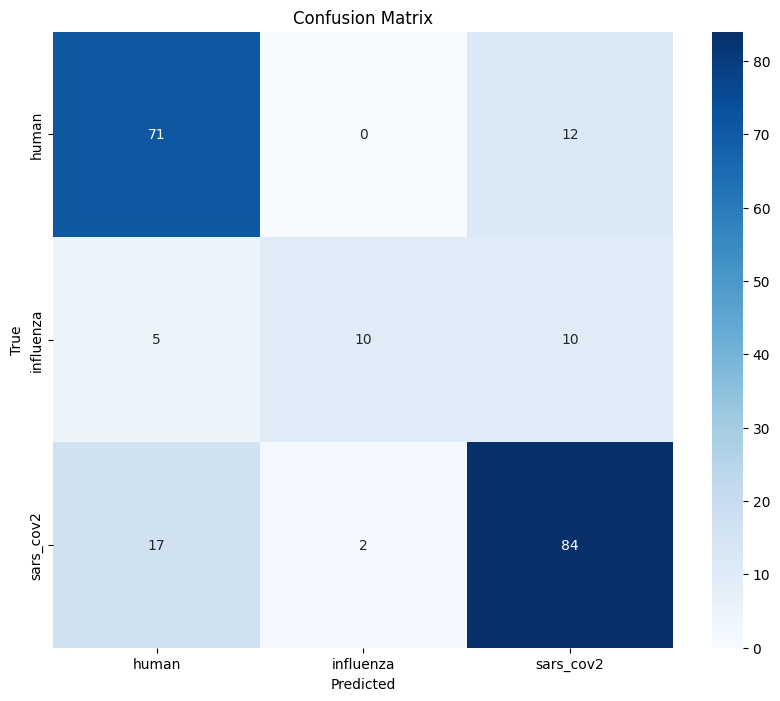

In [26]:
y_true = labels[750:]
print("lens:", len(y_true), len(y_pred))
print("Classification Report:\n", classification_report(y_true, y_pred))
print("Accuracy of the logistic regression model:", accuracy_score(y_true, y_pred))

#plot the confusion matrix
import seaborn as sns
conf_matrix = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(10, 8))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=df_nm["source"].unique(), yticklabels=df_nm["source"].unique())
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()

In [27]:
# loop over all sequences and create the feature matrix
aa_list = "ACDEFGHIKLMNPQRSTVWY-"
n_features = len(aa_list) * (max_length_h3+ max_length_h2 + max_length_h1)

n_data = len(CDR_H3_sequences)
onehot = np.zeros((n_data, n_features), dtype=float)
for i in range(len(CDR_H3_sequences)):
    seq = CDR_H3_sequences[i]+ CDR_H1_sequences[i] + CDR_H2_sequences[i]
    seq_onehot = onehot_of_sequence(seq, aa_list, length=max_length_h3+ max_length_h2 + max_length_h1)
    onehot[i, :] = seq_onehot
print("onehot shape:", onehot.shape)


onehot shape: (961, 1008)


In [28]:
#concatenate the onehot encoding with the extracted data
onehot = np.concatenate((onehot, extracted_data.T), axis=1)
print("onehot shape after concatenation:", onehot.shape)

onehot shape after concatenation: (961, 1020)


In [29]:
#add the other data points to the onehot encoding

In [30]:
# do a PCA on the onehot encoding
from sklearn.decomposition import PCA
pca = PCA(n_components=2)
pca_result = pca.fit_transform(embedding)


In [31]:
import matplotlib.pyplot as plt
df_nm = pd.read_csv("all_data_normalized.tsv", sep="\t")
# Step 6: Create UMAP result DataFrame
color = []
for i in df_nm["source"].values:
    if i == "human":
        color.append("blue")
    elif i == "influenza":
        color.append("orange")
    elif i == "sars_cov2":
        color.append("green")
    else:
        color.append("gray")
plt.figure(figsize=(10, 8))
plt.scatter(pca_result[:, 0], pca_result[:, 1], alpha=0.5,c=color)
plt.title("PCA of CDR Sequences")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.grid()
plt.show()

FileNotFoundError: [Errno 2] No such file or directory: 'all_data_normalized.tsv'

In [ ]:
n_features = len(aa_list) * (max_length_h3)#+ max_length_h2 + max_length_h1)

n_data = len(CDR_H3_sequences)
onehot = np.zeros((n_data, n_features), dtype=int)
for i in range(len(CDR_H3_sequences)):
    seq = CDR_H3_sequences[i]#+ CDR_H1_sequences[i] + CDR_H2_sequences[i]
    seq_onehot = onehot_of_sequence(seq, aa_list, length=max_length_h3)#+ max_length_h2 + max_length_h1)
    onehot[i, :] = seq_onehot
print("onehot shape:", onehot.shape)

onehot shape: (857, 546)


In [ ]:
# do a PCA on the onehot encoding
from sklearn.decomposition import PCA
pca = PCA(n_components=2)
pca_result = pca.fit_transform(onehot)


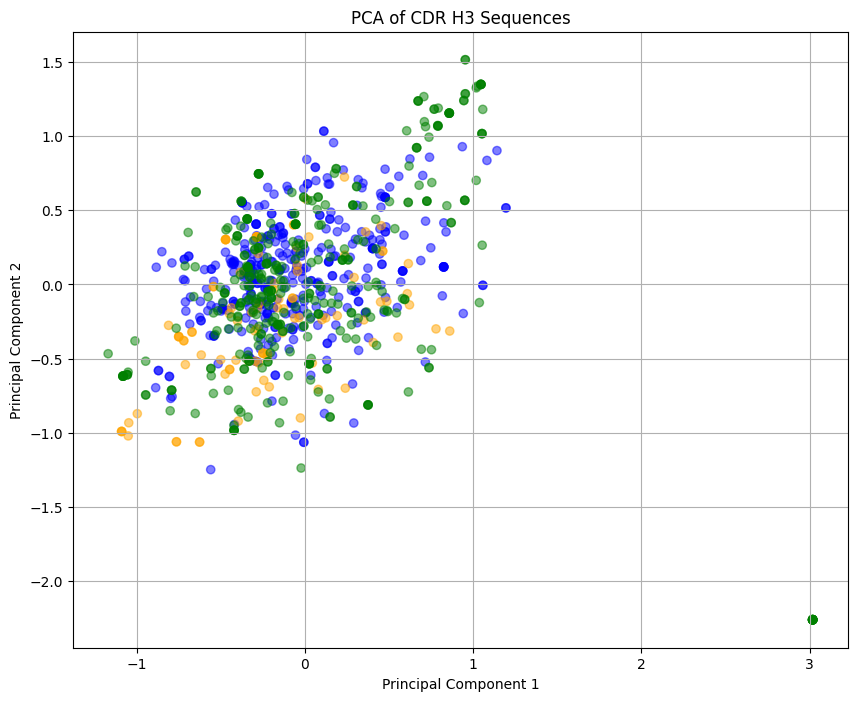

In [ ]:
import matplotlib.pyplot as plt
df_nm = pd.read_csv("all_data_normalized.tsv", sep="\t")
# Step 6: Create UMAP result DataFrame
color = []
for i in df_nm["source"].values:
    if i == "human":
        color.append("blue")
    elif i == "influenza":
        color.append("orange")
    elif i == "sars_cov2":
        color.append("green")
    else:
        color.append("gray")
plt.figure(figsize=(10, 8))
plt.scatter(pca_result[:, 0], pca_result[:, 1], alpha=0.5,c=color)
plt.title("PCA of CDR H3 Sequences")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.grid()
plt.show()

C:\Users\082mi\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
C:\Users\082mi\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


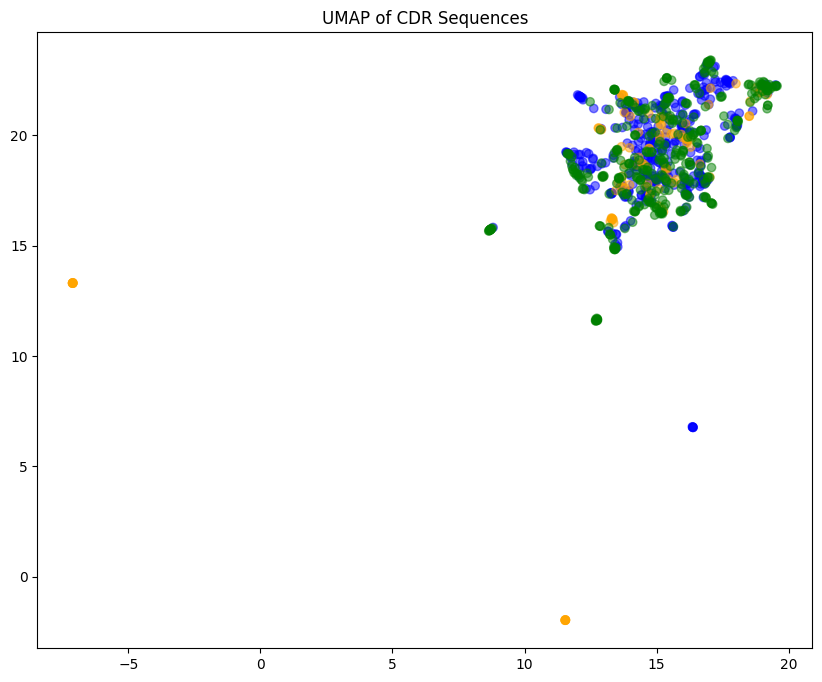

In [ ]:
import umap.umap_ as umap  # UMAP import
umap_model = umap.UMAP(n_components=2, random_state=42)
umap_result = umap_model.fit_transform(onehot)
import matplotlib.pyplot as plt
df_nm = pd.read_csv("all_data_normalized.tsv", sep="\t")
# Step 6: Create UMAP result DataFrame
color = []
for i in df_nm["source"].values:
    if i == "human":
        color.append("blue")
    elif i == "influenza":
        color.append("orange")
    elif i == "sars_cov2":
        color.append("green")
    else:
        color.append("gray")
plt.figure(figsize=(10, 8))
plt.scatter(umap_result[:, 0], umap_result[:, 1], alpha=0.5, c=color)
plt.title("UMAP of CDR Sequences")
plt.show()

In [ ]:
import nbformat
from pathlib import Path
import re

notebooks = Path(".").rglob("*.ipynb")
imports = set()

for nb_path in notebooks:
    try:
        with open(nb_path, "r", encoding="utf-8") as f:
            nb = nbformat.read(f, as_version=4)
            for cell in nb.cells:
                if cell.cell_type == "code":
                    matches = re.findall(r"^\s*(?:import|from)\s+([\w\.]+)", cell.source, re.MULTILINE)
                    imports.update(matches)
    except nbformat.reader.NotJSONError:
        print(f"Skipping invalid notebook: {nb_path}")
        continue

print("Benutzte Imports:")
for imp in sorted(imports):
    print(imp)


Benutzte Imports:
Bio
Bio.Align
Bio.Align.Applications
Bio.Seq
Bio.SeqRecord
matplotlib.colors
matplotlib.pyplot
numpy
os
pandas
pingouin
scipy.cluster.hierarchy
scipy.spatial.distance
scipy.stats
seaborn
sklearn.cluster
sklearn.decomposition
sklearn.linear_model
sklearn.manifold
sklearn.metrics
sklearn.preprocessing
statsmodels.stats.multitest
umap.umap_
